### Unsupervise learning:

- mainly work on forming clusters of the group being formed

- Clustering Groups:
1. K means Clustering
2. Hierarichal Clustering
3. DBSCAN Clustering

### Kmeans:

- tend to form a cluster based on the centriod being plotted where it try to develope the relation between the nearer dataset using eucledian or manhatten approach and accordingly start forming cluster
- value of grouping(cluster) can be depend upon requirement
- dtermine the correct number of cluster (k) using is been done by means of "Elbow technique"
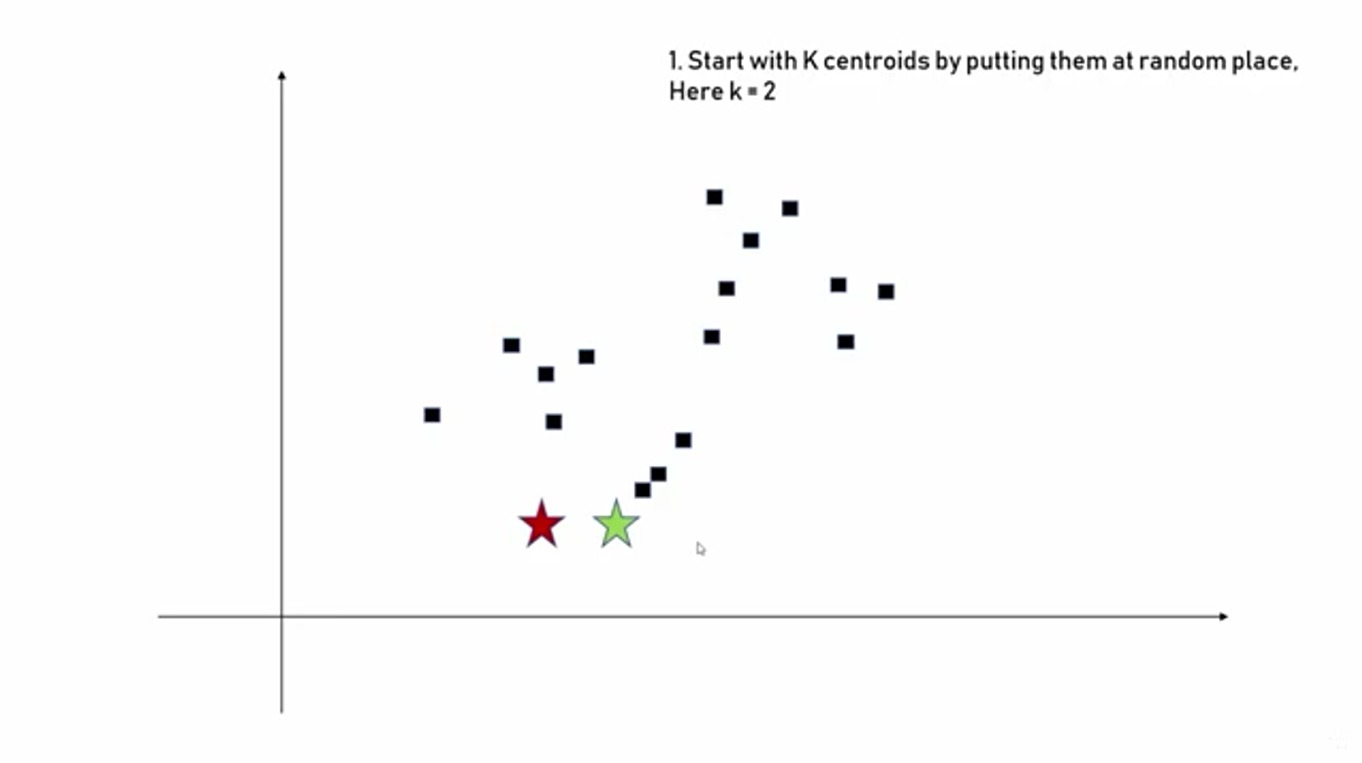

In [2]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import minmax_scale
import matplotlib.pyplot as plt

In [8]:
data = {
    "Name": [
        "Aman","Bhavna","Chetan","Divya","Eshan",
        "Farah","Gaurav","Hina","Ishan","Jiya","Karan","Lavanya",
        "Manish","Neha","Omkar","Pooja","Qasim","Ritika","Sahil","Tanvi","Uday","Varsha","Yash"
    ],

    "Age": [
        22,24,25,23,26,
        32,35,34,33,36,31,37,
        45,48,50,46,47,52,44,49,51,53,55
    ],

    "Income": [
        20000,22000,25000,23000,27000,
        40000,42000,45000,43000,47000,41000,48000,
        80000,85000,90000,82000,87000,92000,78000,88000,91000,94000,96000
    ]
}

In [9]:
df = pd.DataFrame(data)
df

,Name,Age,Income
0,Aman,22,20000
1,Bhavna,24,22000
2,Chetan,25,25000
3,Divya,23,23000
4,Eshan,26,27000
5,Farah,32,40000
6,Gaurav,35,42000
7,Hina,34,45000
8,Ishan,33,43000
9,Jiya,36,47000


In [10]:
df.head()

,Name,Age,Income
0,Aman,22,20000
1,Bhavna,24,22000
2,Chetan,25,25000
3,Divya,23,23000
4,Eshan,26,27000


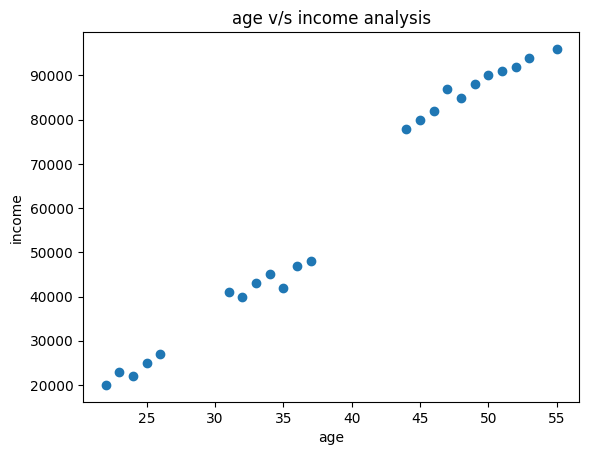

In [12]:
plt.scatter(df['Age'],df['Income'])
plt.xlabel('age')
plt.ylabel('income')
plt.title('age v/s income analysis')
plt.show()

In [13]:
km = KMeans(n_clusters=3)
y_pred = km.fit_predict(df[['Age', 'Income']])
y_pred

array([0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1], dtype=int32)

In [17]:
df['cluster'] = y_pred
df.sample(n=4) # instead of head, tail to get random iteration go for sample()

,Name,Age,Income,cluster
14,Omkar,50,90000,1
17,Ritika,52,92000,1
9,Jiya,36,47000,2
2,Chetan,25,25000,0


In [18]:
km.cluster_centers_ # tells the centriod information

array([[2.40000000e+01, 2.34000000e+04],
       [4.90909091e+01, 8.75454545e+04],
       [3.40000000e+01, 4.37142857e+04]])

In [19]:
df1 = df[df['cluster']==0]
df2 = df[df['cluster']==1]
df3 = df[df['cluster']==2]

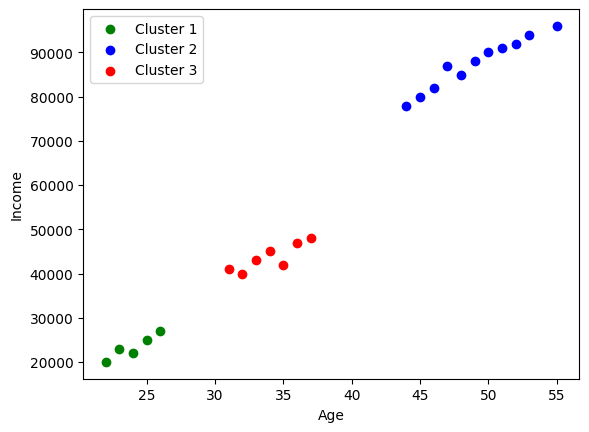

In [31]:
plt.scatter(df1.Age, df1['Income'], color='green', label='Cluster 1')
plt.scatter(df2.Age, df2['Income'], color='blue', label='Cluster 2')
plt.scatter(df3.Age, df3['Income'], color='red', label='Cluster 3')

plt.xlabel('Age')
plt.ylabel('Income')

plt.legend()
plt.show()

In [ ]:
scaler = minmax_scaler()

In [ ]:
scaler.fit(df[['Income']])
df['Income'] = scaler.transform(df[['Income']])

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

df.head()

In [ ]:
km = KMeans(n_clusters=3)
y_pred = km.fit_predict(df[['Age', 'Income']])
y_pred

In [ ]:
df['cluster'] = y_pred
df.sample(n=4)

In [ ]:
km.cluster_centers_ 

In [ ]:
df1 = df[df['cluster']==0]
df2 = df[df['cluster']==1]
df3 = df[df['cluster']==2]

In [ ]:
plt.scatter(df1.Age, df1['Income'], color='green', label='Cluster 1')
plt.scatter(df2.Age, df2['Income'], color='blue', label='Cluster 2')
plt.scatter(df3.Age, df3['Income'], color='red', label='Cluster 3')

plt.xlabel('Age')
plt.ylabel('Income')

plt.legend()
plt.show()

### elbow graph

In [34]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age', 'Income']])
    sse.append(km.inertia_)

In [35]:
sse

[17320437361.565216,
 1624977723.3030303,
 421356003.064935,
 172235803.03571427,
 120495294.89523807,
 74616705.83333334,
 78761943.26190476,
 33000023.916666664,
 29000017.666666664]

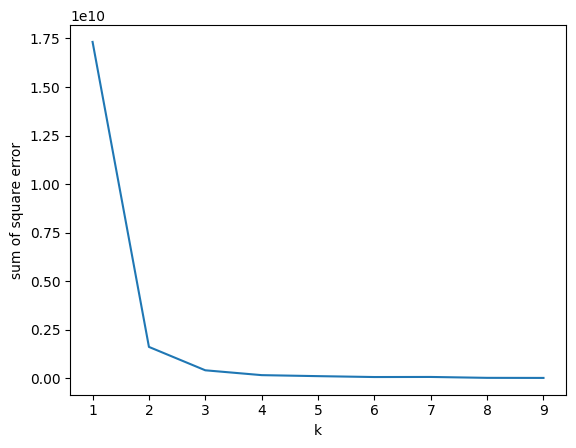

In [36]:
plt.xlabel('k')
plt.ylabel('sum of square error')
plt.plot(k_rng,sse)